# 02 · Surface context: the RF20 PRE-event surface classification

Context layer of Paper 3: evaluation strata for the U-Net arms and the classes of the disagreement ontology. Reference = ESA WorldCover 2021, the training reference — these are *agreement* numbers, not validation.

**Reading rules.** Every model number is *agreement with weak reference labels*, never flood-mapping accuracy. "Not observed is not dry." Areas carry their semantics (observed_S1 / mapped_UNet / terrain_reconstructed / literature_reported). Evidence levels: independent_physical › cross_sensor › weak_label_agreement › contextual.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "case_studies/kakhovka_2023/tables").exists())
CS = ROOT / "case_studies/kakhovka_2023"; T = CS / "tables"; PT = CS / "publication/tables"; PF = CS / "publication/figures"; RUNS = CS / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
C = {"terrain": "#2a78d6", "s1": "#eb6834", "unet": "#4a3aa7", "rf": "#1baf7a", "gauge": "#52514e"}
def show(tid, n=None):
    df = pd.read_csv(PT / f"{tid}.csv"); cap = json.loads((PT / "manifest.json").read_text())["tables"][tid]
    display(Markdown(f"**{tid}** [{cap['evidence_level']}] {cap['caption']}")); return df.head(n) if n else df
def fig(name): p = next(PF.glob(name + "*.png"), None); display(Image(str(p), width=900)) if p else print("figure not rendered yet:", name)
print("repo:", ROOT)

repo: /home/niko/repo/floodstate-eo


## 1. Per-class agreement (spatial-block 5-fold CV and frame transfers)

In [2]:
show('T09')

**T09** [contextual] RF20 surface classification: per-class precision / recall / F1 with support, macro means and overall agreement, spatial-block 5-fold CV and frame transfers. Reference = WorldCover 2021, the training reference.

,evaluation,cls,precision,recall,F1,n,OA_spatial_cv,kappa_spatial_cv_csv_only,reference
0,spatial_block_cv_5fold,WATER,0.9983,0.9986,0.9984,60000,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
1,spatial_block_cv_5fold,CROPLAND,0.9196,0.9284,0.9240,60000,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
2,spatial_block_cv_5fold,GRASS_LOW_VEGETATION,0.8735,0.8753,0.8744,60000,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
3,spatial_block_cv_5fold,FOREST,0.9372,0.9319,0.9345,60000,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
4,spatial_block_cv_5fold,WETLAND_REED,0.9690,0.9372,0.9528,60000,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
5,spatial_block_cv_5fold,BUILT_UP,0.9180,0.9594,0.9382,60000,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
6,spatial_block_cv_5fold,BARE_SAND,0.9961,0.9618,0.9786,32420,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
7,spatial_block_cv_5fold,MACRO,0.9445,0.9418,0.9430,392420,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
8,spatial_block_cv_5fold,OVERALL_ACCURACY,NaN,NaN,0.9404,392420,0.9404,0.9301,ESA WorldCover 2021 (training reference; agree...
9,transfer_B1_to_B2,WATER,0.9978,0.9992,0.9985,30000,NaN,NaN,ESA WorldCover 2021 (training reference; agree...


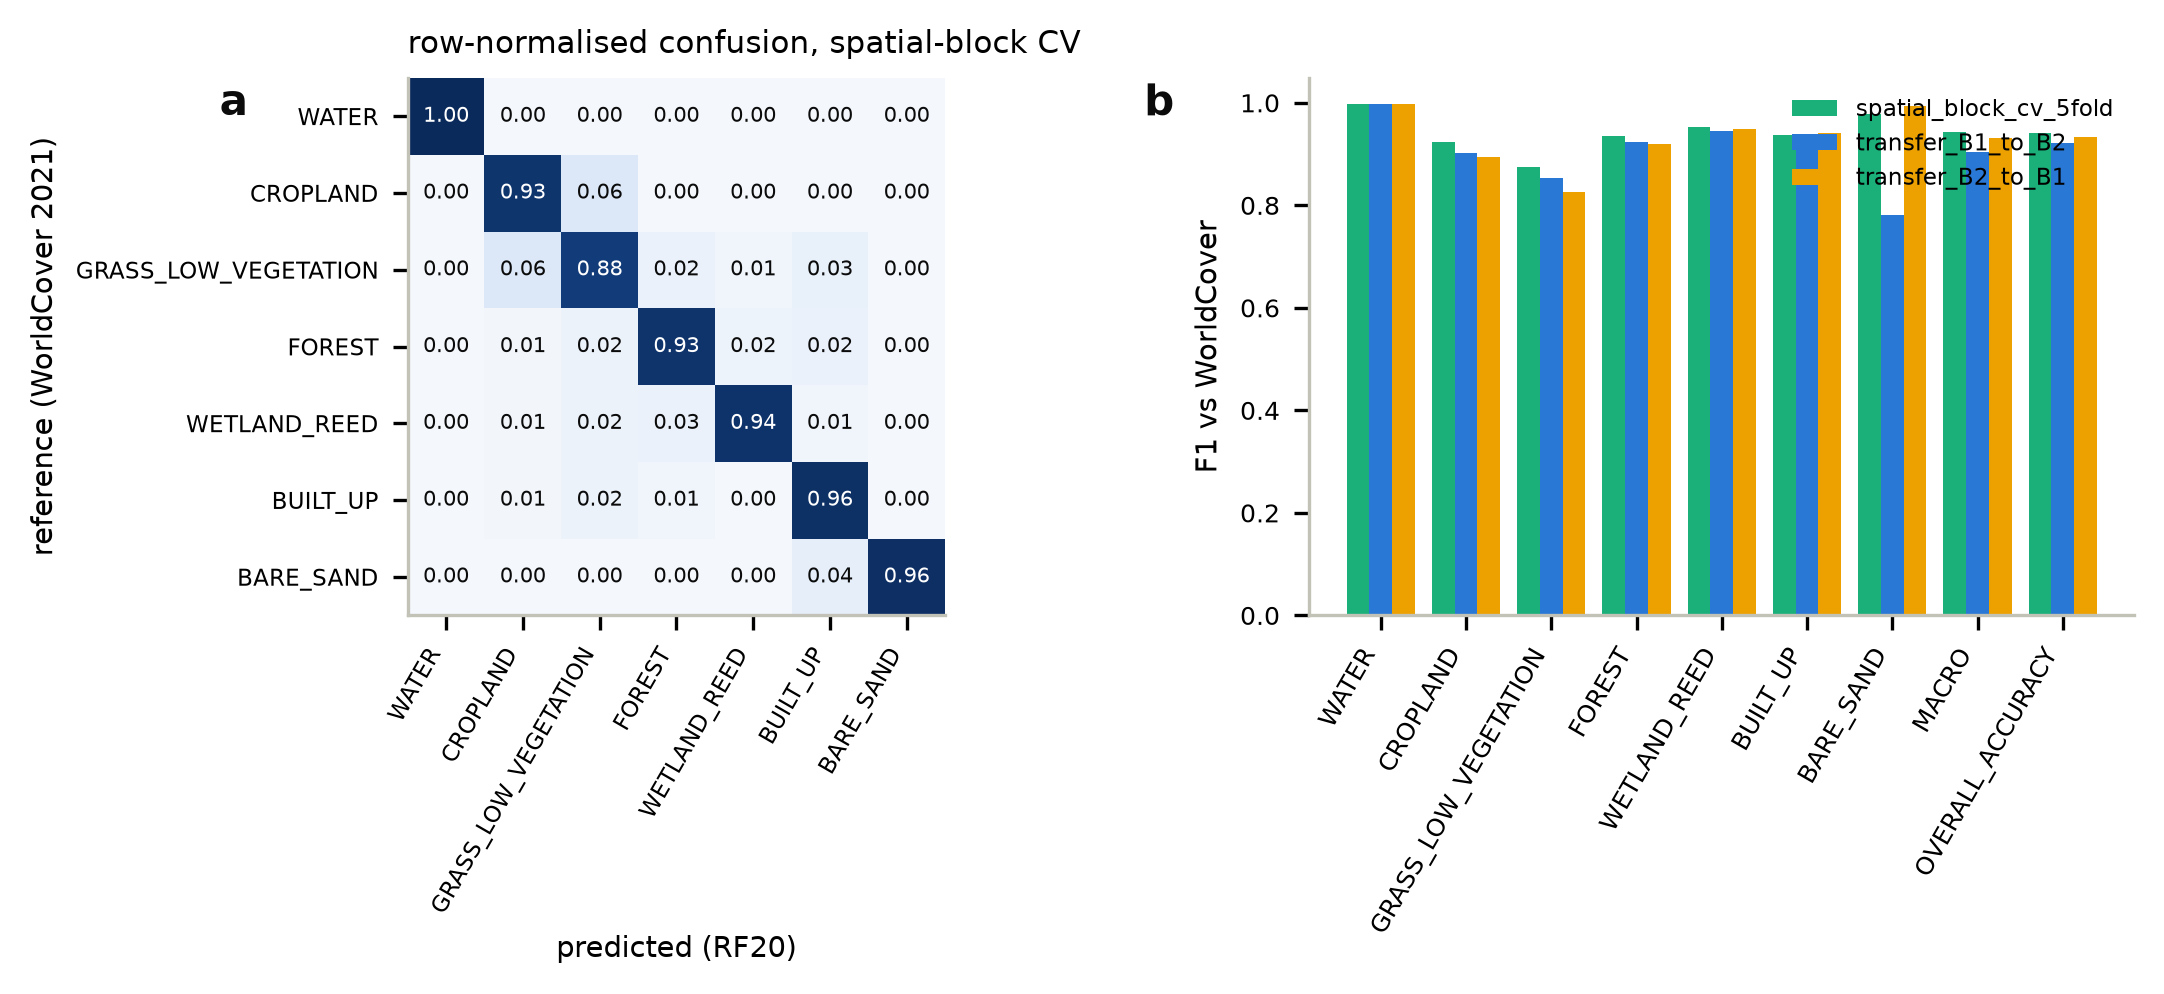

In [3]:
fig('FigS04')

## 2. Confusion matrix and class areas

In [4]:
show('T10'); show('T10b')

**T10** [contextual] RF20 confusion matrix (spatial-block CV, counts).

**T10b** [contextual] RF20 class areas per frame, km2 (mapped areas of a context product).

,frame,p73_class,km2,share_pct
0,B1,WATER,152.42,2.50
1,B1,CROPLAND,3304.25,54.24
2,B1,GRASS_LOW_VEGETATION,1044.65,17.15
3,B1,FOREST,552.81,9.07
4,B1,SHRUB,0.00,0.00
5,B1,WETLAND_REED,293.35,4.82
6,B1,BUILT_UP,275.05,4.52
7,B1,BARE_SAND,116.03,1.90
8,B1,OTHER,0.00,0.00
9,B1,UNCERTAIN,353.13,5.80


## 3. Wall-to-wall agreement with WorldCover (crosswalk, not validation)

In [5]:
show('T10c')

**T10c** [contextual] RF20 vs WorldCover wall-to-wall agreement on WorldCover-pure cells (recall / precision vs the training reference).

,frame,p73_class,worldcover,wc_pure_km2,recall_vs_wc,precision_vs_wc
0,B1,WATER,water,173.5,0.8640,0.9956
1,B1,CROPLAND,cropland,3397.2,0.9324,0.9873
2,B1,GRASS_LOW_VEGETATION,grass,918.4,0.7962,0.8535
3,B1,FOREST,tree,448.8,0.9281,0.9436
4,B1,SHRUB,shrub,0.0,0.0000,0.0000
5,B1,WETLAND_REED,herb_wetland,239.5,0.9300,0.9217
6,B1,BUILT_UP,built,140.8,0.9431,0.8205
7,B1,BARE_SAND,bare,27.2,0.9935,0.3989
8,B1,OTHER,snow,0.0,0.0000,0.0000
9,B1,OTHER,mangrove,0.0,0.0000,0.0000


## 4. QA verdict and known limitations (p73 freeze)

In [6]:
print((T / 'p73_rf20_qa' / 'QA_VERDICT.md').read_text()[:6000])

# p73 RF20 — QA verdict: PASS with documented limitations → P73_RF20_FROZEN (2026-09-23)

Producing commit `5f875ce` (clean worktree, `dirty_tracked: false`); model sha256 in `../p73_rf20_manifest.json`.

## Reproducibility gate — PASS
The clean-worktree runs at `dd8c096` and `5f875ce` reproduce the development result (produced on a dirty tree at
`a875e99`) **bit for bit** — class and max-score rasters, both frames, 0 differing cells. p73 does not depend on the
uncommitted `_kakhovka_legacy_config.py` CRS fix / manifests / UNRESOLVED_DEPENDENCIES diffs.

## Statistical QA (evaluation against WorldCover 2021, itself a weak reference — not ground truth)
| | CROPLAND F1 | WETLAND_REED F1 | BUILT_UP F1 | BARE_SAND F1 | WATER F1 | OA |
|---|---|---|---|---|---|---|
| 5-fold 5 km spatial-block CV | 0.924 | 0.953 | 0.938 | 0.979 | 0.998 | 0.940 |
| transfer B1 → B2 | 0.901 | 0.946 | 0.923 | 0.780 (n=2 420) | 0.999 | 0.923 |
| transfer B2 → B1 | 0.895 | 0.949 | 0.942 | 0.993 | 0.998 | 0.933 |


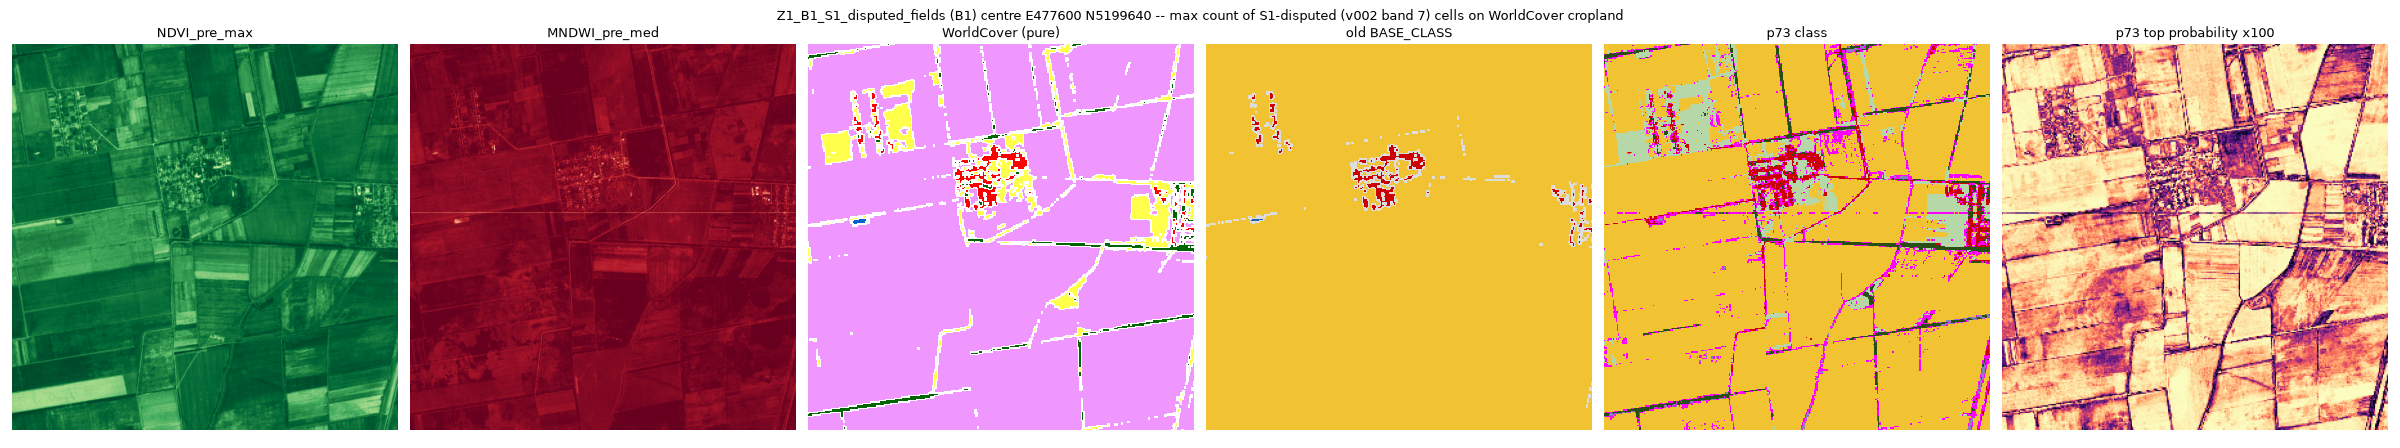

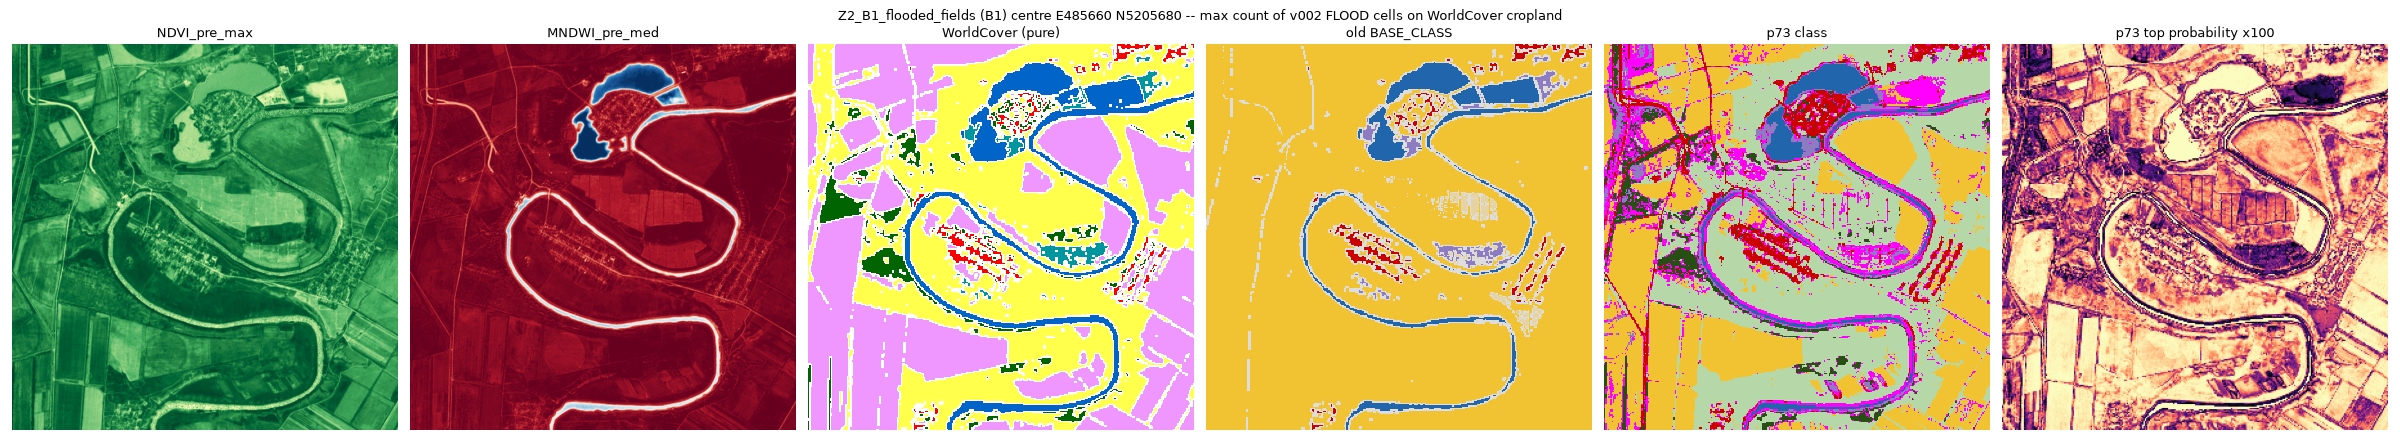

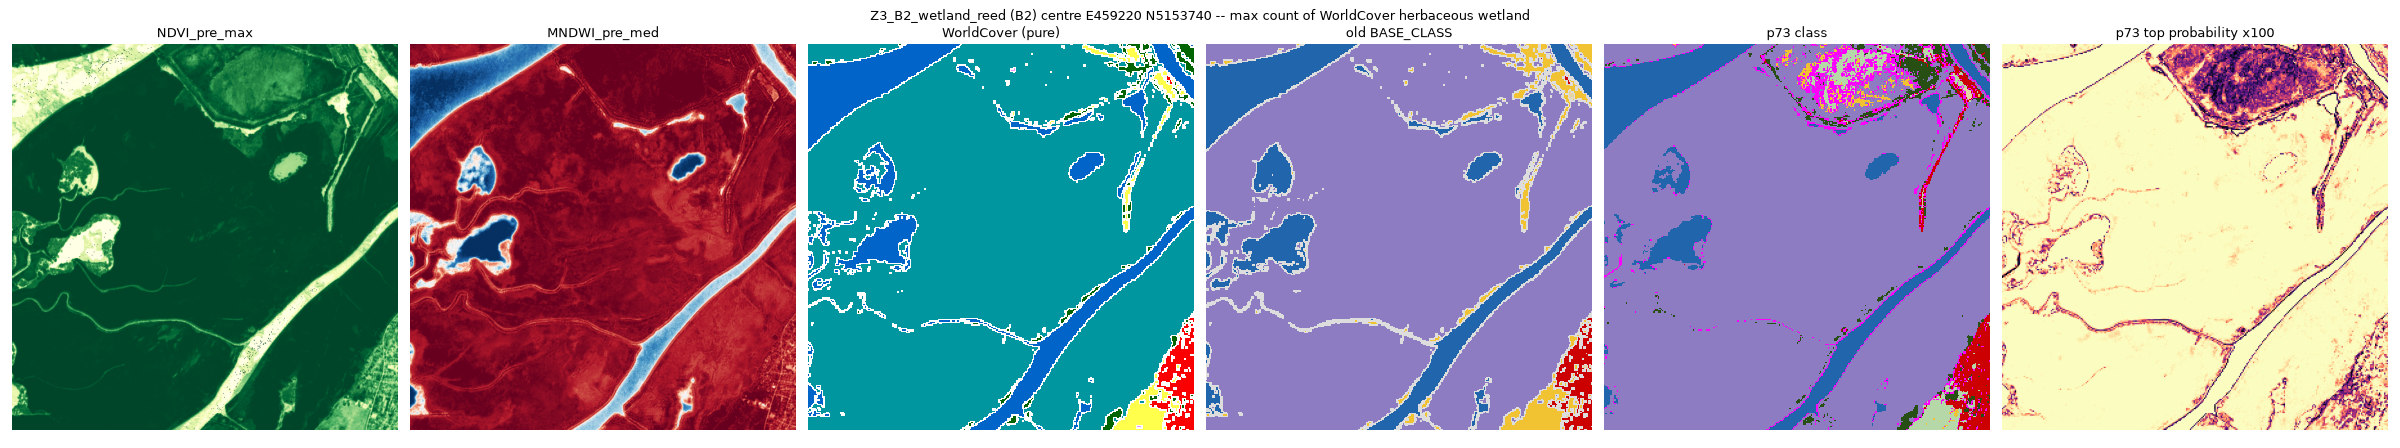

In [7]:
for p in sorted((T / 'p73_rf20_qa').glob('Z*.png'))[:3]: display(Image(str(p), width=800))